# 篇末综合 拟合、稀疏与约束优化

## 学习目标与先修知识

在统一尺度与信息边界下构造目标、实现下降与稀疏拟合，并核验约束解。

先修：本篇8.1—8.4。 [本篇学习次序](../README.md)。

## 具体问题

完成一次小型物质收支（mass balance）拟合与资源配置：先从观测（observation）拟合两个候选项，再在独立阶段约束两路输入（input）。拟合系数与决策变量属于不同问题，不能把同一向量（vector）名称当作相同生理意义。

In [1]:
import math
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "DejaVu Sans"]
BLUE, PINK, GREEN, GRAY = "#327cac", "#c35178", "#338b7c", "#68768a"

## 初步实验

In [2]:
X=np.array([[1.,.2],[.5,1.],[1.2,.8],[.2,1.3]])
y=np.array([1.12,.95,1.65,.83]);n=len(y);H=X.T@X/n;b=X.T@y/n
print('拟合曲率特征值',np.linalg.eigvalsh(H))

拟合曲率特征值 [0.275879 1.249121]


## 模型假设

第一任务的字典和观测均为无量纲（dimensionless）人工数据，λ与步长规则预先给定，不把它们作为生理结论。第二任务采用独立给定的正定（positive definite）决策代价，两个输入按同一参考流量（flow）缩放。目标、信息、预算、返回结论标签分别记录，核验值不用于挑选算法结果。

## 数学解释与推导


拟合任务从 $J=\|X\beta-y\|^2/(2n)$ 出发，其 $H=X^TX/n$、$b=X^Ty/n$。
省略常数 $y^Ty/(2n)$ 只改变目标数值的基准；报告MSE时必须加回。
二次最优点用 $H\beta=b$ 核验，梯度（gradient）步用谱界，稀疏目标用次梯度（subgradient）条件。
固定λ的稀疏解不自动比无惩罚解有更小训练误差，也不自动识别真实机制。

资源配置任务为 $\min_x x^TH_dx/2-b_d^Tx$，受上下界和总预算约束。
先证可行，再计算候选，再以原始、对偶、驻点（stationary point）和互补残差（residual）检查；这些步骤不能被一个成功结论标签标签替代。
迁移时分别改变观测、惩罚、预算和最低需求，只比较同一目标下的代价。


## 核心实现

按上述推导逐步计算；保留明确的更新预算与返回标签。

In [3]:
def quadratic(matrix, linear, point):
    """f(x)=xᵀHx/2-bᵀx; inputs use the same dimensionless coordinates."""
    gradient = [sum(a*x for a, x in zip(row, point))-b
                for row, b in zip(matrix, linear)]
    value = sum(x*(g-b) for x, g, b in zip(point, gradient, linear))/2
    return value, gradient, [list(row) for row in matrix]


def solve_linear(matrix, right):
    """Partial-pivot elimination for the tiny classroom systems."""
    rows = [list(map(float, row))+[float(value)] for row, value in zip(matrix, right)]
    size = len(rows)
    for column in range(size):
        pivot = max(range(column, size), key=lambda i: abs(rows[i][column]))
        if abs(rows[pivot][column]) < 1e-12:
            return None
        rows[column], rows[pivot] = rows[pivot], rows[column]
        scale = rows[column][column]
        rows[column] = [value/scale for value in rows[column]]
        for i in range(size):
            if i != column:
                factor = rows[i][column]
                rows[i] = [a-factor*b for a, b in zip(rows[i], rows[column])]
    return [row[-1] for row in rows]


def gradient_descent(matrix, linear, initial, step, max_steps, tolerance):
    point = list(initial)
    history = [point[:]]
    for iteration in range(max_steps+1):
        value, gradient, _ = quadratic(matrix, linear, point)
        residual = math.hypot(*gradient)
        if not math.isfinite(residual) or not math.isfinite(value):
            return history, None, 'nonfinite'
        if residual <= tolerance:
            return history, residual, 'converged'
        if iteration == max_steps:
            return history, residual, 'max_steps'
        point = [x-step*g for x, g in zip(point, gradient)]
        history.append(point[:])


def armijo_quadratic(matrix, linear, point, direction, initial_step, shrink, slope, max_trials):
    value, gradient, _ = quadratic(matrix, linear, point)
    derivative = sum(a*b for a, b in zip(gradient, direction))
    if derivative >= 0:
        return list(point), None, 'not_descent'
    step = initial_step
    for _ in range(max_trials):
        trial = [x+step*p for x, p in zip(point, direction)]
        candidate = quadratic(matrix, linear, trial)[0]
        if math.isfinite(candidate) and candidate <= value+slope*step*derivative:
            return trial, step, 'accepted'
        step *= shrink
    return list(point), None, 'line_search_failed'


def soft_threshold(values, threshold):
    return [math.copysign(max(abs(value)-threshold, 0.), value) if abs(value)>threshold else 0.
            for value in values]


def proximal_step(design, observed, coefficients, step, penalty):
    count = len(design)
    residuals = [sum(x*b for x, b in zip(row, coefficients))-y
                 for row, y in zip(design, observed)]
    gradient = [sum(row[j]*r for row, r in zip(design, residuals))/count
                for j in range(len(coefficients))]
    updated = soft_threshold([b-step*g for b, g in zip(coefficients, gradient)], step*penalty)
    errors = [sum(x*b for x, b in zip(row, updated))-y for row, y in zip(design, observed)]
    value = sum(r*r for r in errors)/(2*count)+penalty*sum(abs(b) for b in updated)
    return updated, value


def proximal_trace(design, observed, initial, step, penalty, steps):
    history = [list(initial)]
    objectives = [proximal_step(design, observed, initial, 0., penalty)[1]]
    for _ in range(steps):
        point, value = proximal_step(design, observed, history[-1], step, penalty)
        history.append(point); objectives.append(value)
    return history, objectives


def box_budget_qp(matrix, linear, lower, upper, budget):
    """Two variables, positive definite objective; enumerate independent active normals."""
    if any(a>b for a, b in zip(lower, upper)) or sum(lower)>budget:
        return None, None, 'infeasible'
    constraints = [[-1.,0.],[0.,-1.],[1.,0.],[0.,1.],[1.,1.]]
    bounds = [-lower[0],-lower[1],upper[0],upper[1],budget]
    candidates = []
    for size in range(3):
        for active in combinations(range(5), size):
            rows = [constraints[i] for i in active]
            block = [list(matrix[i])+[row[i] for row in rows] for i in range(2)]
            block += [list(row)+[0.]*size for row in rows]
            solution = solve_linear(block, list(linear)+[bounds[i] for i in active])
            if solution is None:
                continue
            point, multipliers = solution[:2], solution[2:]
            if any(sum(a*x for a, x in zip(row, point))-bound>1e-9 for row, bound in zip(constraints,bounds)):
                continue
            if any(value < -1e-9 for value in multipliers):
                continue
            candidates.append((quadratic(matrix,linear,point)[0], point))
    if not candidates:
        return None, None, 'numerical_failure'
    value, point = min(candidates, key=lambda item:item[0])
    return point, value, 'optimal'


def kkt_residuals(matrix, linear, constraints, bounds, point, multipliers, tolerance):
    _, gradient, _ = quadratic(matrix, linear, point)
    violation = [sum(a*x for a, x in zip(row, point))-c for row, c in zip(constraints, bounds)]
    stationarity = [g+sum(row[j]*v for row, v in zip(constraints, multipliers))
                    for j, g in enumerate(gradient)]
    primal = max([0.]+violation)
    dual = max([0.]+[-value for value in multipliers])
    stationary = max([0.]+[abs(x) for x in stationarity])
    complementary = max([0.]+[abs(v*r) for v, r in zip(multipliers, violation)])
    residuals = [primal, dual, stationary, complementary]
    return residuals, 'verified' if max(residuals)<=tolerance else 'rejected'


def budget_certificate(matrix, linear, lower, upper, budget):
    point, value, status = box_budget_qp(matrix, linear, lower, upper, budget)
    if point is None:
        return None, None, None, status
    constraints = [[-1.,0.],[0.,-1.],[1.,0.],[0.,1.],[1.,1.]]
    bounds = [-lower[0],-lower[1],upper[0],upper[1],budget]
    gradient = quadratic(matrix, linear, point)[1]
    tight = [i for i,(row,c) in enumerate(zip(constraints,bounds))
             if abs(sum(a*x for a,x in zip(row,point))-c)<1e-8]
    for size in range(3):
        for active in combinations(tight,size):
            rows = [constraints[i] for i in active]
            gram = [[sum(a*b for a,b in zip(r,s)) for s in rows] for r in rows]
            right = [-sum(a*g for a,g in zip(row,gradient)) for row in rows]
            weights = solve_linear(gram,right) if size else []
            if weights is None or any(w < -1e-8 for w in weights):
                continue
            multipliers = [0.]*5
            for i,w in zip(active,weights): multipliers[i]=w
            residuals,check = kkt_residuals(matrix,linear,constraints,bounds,point,multipliers,1e-8)
            if check=='verified':
                return point,value,residuals,'optimal'
    return point,value,None,'numerical_failure'

## 对照实验

| 方法 | 系数1 | 系数2 |
| --- | --- | --- |
| 无惩罚解析 | 1.04231 | 0.466396 |
| 梯度迭代 | 1.04231 | 0.466396 |
| L1固定惩罚 | 0.916084 | 0.395881 |

| 预算 | 决策配置 | 目标 | 四残差 | 状态 |
| --- | --- | --- | --- | --- |
| 0.7 | None | None | None | infeasible |
| 1 | [0.5, 0.5] | -4.25 | [0.0, 0.0, 0.0, 0.0] | optimal |
| 1.5 | [0.5, 0.9999999999999999] | -6 | [0.0, 0.0, 4.440892098500626e-16, 0.0] | optimal |
| 2 | [0.7500000000000001, 1.25] | -7.125 | [0.0, 0.0, 0.0, 0.0] | optimal |
| 3 | [1.375, 1.625] | -8.28125 | [0.0, 0.0, 0.0, 0.0] | optimal |
| 5 | [1.565217391304348, 1.7391304347826086] | -8.34783 | [0.0, 0.0, 0.0, 0.0] | optimal |

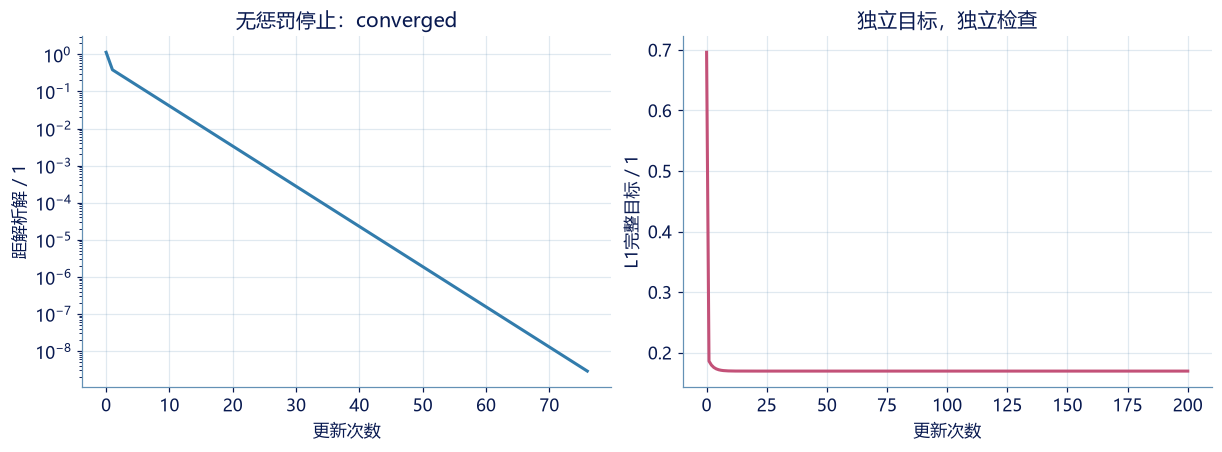

In [4]:
L=np.linalg.eigvalsh(H)[-1]
gd,residual,status=gradient_descent(H.tolist(),b.tolist(),[0.,0.],1/L,200,1e-9)
sparse,values=proximal_trace(X.tolist(),y.tolist(),[0.,0.],1/L,.12,200)
exact=np.linalg.solve(H,b)
display(Markdown(show_table(['方法','系数1','系数2'],[['无惩罚解析',*exact],['梯度迭代',*gd[-1]],['L1固定惩罚',*sparse[-1]]])))
Hd=[[2.,.5],[.5,3.]];bd=[4.,6.];budgets=[.7,1.,1.5,2.,3.,5.];rows=[]
for B in budgets:
    point,cost,certificate,result=budget_certificate(Hd,bd,[.5,.5],[3.,3.],B)
    rows.append([B,point,cost,certificate,result])
display(Markdown(show_table(['预算','决策配置','目标','四残差','状态'],rows)))
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].semilogy(np.maximum(np.linalg.norm(np.array(gd)-exact,axis=1),1e-16),color=BLUE)
axes[0].set(xlabel='更新次数',ylabel='距解析解 / 1',title=f'无惩罚停止：{status}')
axes[1].plot(values,color=PINK);axes[1].set(xlabel='更新次数',ylabel='L1完整目标 / 1',title='独立目标，独立检查');plt.show()

### 独立核验与边界

In [5]:
np.testing.assert_allclose(gd[-1],exact,atol=1e-8)
assert residual<=1e-9 and status=='converged'
beta=np.array(sparse[-1]);gradient=X.T@(X@beta-y)/n
stationarity=np.where(np.abs(beta)>1e-9,np.abs(gradient+.12*np.sign(beta)),np.maximum(np.abs(gradient)-.12,0))
assert max(stationarity)<1e-7
for B,point,cost,certificate,result in rows:
    if B<1:assert result=='infeasible' and point is None
    else:assert result=='optimal' and max(certificate)<1e-8 and sum(point)<=B+1e-10
for beta in [exact,np.array(gd[-1]),np.array(sparse[-1])]:
    np.testing.assert_allclose(quadratic(H,b,beta)[0]+y@y/(2*n),np.mean((X@beta-y)**2)/2)
print('两种拟合残差、目标常数、约束可行性及最优性证据均通过。')

两种拟合残差、目标常数、约束可行性及最优性证据均通过。


## 结果解释

本综合的核心是让每个结论都对应检查：导数（derivative）靠差分与解析代数，迭代靠步长条件与残差，稀疏靠完整目标和次梯度，约束靠可行性与KKT。练习按四层组织，最终迁移包含零预算和不可行情形。

## 练习与参考资料

先独立作答，再提交核对。

本篇综合题按基础辨析、方法应用、综合验证、迁移挑战递进，共 100 分。每题独立作答；正确选择或完整测试通过得该题全部分值。网页分别汇总首次作答分与练习达成分，支持按层次和学习目标复习。

### 第 1 题 · 基础辨析 · 10 分 · 多项选择题：目标尺度与凸性

拟合目标f(x)=xᵀHx/2−bᵀx。H对称。哪些判断正确？

- **A.** H正定（positive definite）时唯一驻点（stationary point）就是全局最小。
- **B.** H只有在当前点半正定（positive semidefinite）就足以证明任意非线性目标凸。
- **C.** 统一正比例缩放目标不改变最小点。
- **D.** 梯度（gradient）为零对一般非凸目标仍需进一步检查。

[作答：目标尺度与凸性](http://127.0.0.1:8000/parts/08-%E4%BC%98%E5%8C%96%E6%96%B9%E6%B3%95%E4%B8%8E%E8%AE%A1%E7%AE%97/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p08-cap-geometry)

### 第 2 题 · 基础辨析 · 10 分 · 多项选择题：正则化能保证什么

用相关机制字典拟合清除数据，验证集（validation set）选择λ。哪些结论合理？

- **A.** 稀疏选择可以代替独立机制证据。
- **B.** λ>0的岭目标可在列相关时给出唯一解。
- **C.** 最终测试误差不是训练损失的必然单调函数。
- **D.** 列尺度改变会影响同一λ所代表的惩罚。

[作答：正则化能保证什么](http://127.0.0.1:8000/parts/08-%E4%BC%98%E5%8C%96%E6%96%B9%E6%B3%95%E4%B8%8E%E8%AE%A1%E7%AE%97/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p08-cap-regularization)

### 第 3 题 · 方法应用 · 15 分 · Python 计算题：梯度与曲率核验

对已经给定的无量纲（dimensionless）二次拟合目标，返回目标、梯度（gradient）及海森矩阵（Hessian matrix），供独立差分核对。

**函数与代码模板**

```python
def solve(
    matrix: list[list[float]],
    linear: list[float],
    point: list[float],
) -> tuple[float, list[float], list[list[float]]]:
    # 按题目说明计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `matrix` | `list[list[float]]` | 对称目标矩阵（matrix） H，目标为 xᵀHx/2−bᵀx。 | 无量纲 |
| `linear` | `list[float]` | 线性项 b，符号按目标中的减号。 | 无量纲 |
| `point` | `list[float]` | 当前优化变量 x。 | 无量纲 |

**返回值**

按以下顺序返回元组：(value, gradient, hessian)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `value` | `float` | 目标值 f(x)。 | 无量纲 |
| `gradient` | `list[float]` | 梯度 Hx−b。 | 无量纲 |
| `hessian` | `list[list[float]]` | 海森矩阵，等于 H。 | 无量纲 |

**计算规则**

按 f=xᵀHx/2−bᵀx 计算；不要漏掉 1/2，也不要把 b 的符号改为加号。

**约束与边界**

- 1≤维数≤3；H对称，所有元素绝对值≤20。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| matrix | 对称目标矩阵（matrix） H，目标为 xᵀHx/2−bᵀx。 | [[2.0, 1.0], [1.0, 4.0]] | 无量纲 |
| linear | 线性项 b，符号按目标中的减号。 | [1.0, 2.0] | 无量纲 |
| point | 当前优化变量 x。 | [2.0, -1.0] | 无量纲 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
matrix = [[2.0, 1.0], [1.0, 4.0]]
linear = [1.0, 2.0]
point = [2.0, -1.0]

result = solve(matrix, linear, point)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| value | 目标值 f(x)。 | 4 | 无量纲 |
| gradient | 梯度 Hx−b。 | [2.0, -4.0] | 无量纲 |
| hessian | 海森矩阵，等于 H。 | [[2.0, 1.0], [1.0, 4.0]] | 无量纲 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (4.0,
                   [2.0, -4.0],
                   [[2.0, 1.0], [1.0, 4.0]])
```

**样例解释**

先算 Hx=[3,−2]，梯度=[2,−4]；目标值为4。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：梯度与曲率核验](http://127.0.0.1:8000/parts/08-%E4%BC%98%E5%8C%96%E6%96%B9%E6%B3%95%E4%B8%8E%E8%AE%A1%E7%AE%97/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p08-cap-derivatives)

### 第 4 题 · 方法应用 · 15 分 · Python 计算题：带回溯的一步下降

给定同一拟合目标、起点和方向，按公开的有限回溯规则返回接受步长与新点。

**函数与代码模板**

```python
def solve(
    matrix: list[list[float]],
    linear: list[float],
    point: list[float],
    direction: list[float],
    initial_step: float,
    shrink: float,
    slope: float,
    max_trials: int,
) -> tuple[list[float], float | None, str]:
    # 按题目说明计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `matrix` | `list[list[float]]` | 对称目标矩阵（matrix） H，目标为 xᵀHx/2−bᵀx。 | 无量纲 |
| `linear` | `list[float]` | 线性项 b，符号按目标中的减号。 | 无量纲 |
| `point` | `list[float]` | 当前优化变量 x。 | 无量纲 |
| `direction` | `list[float]` | 固定搜索方向p。 | 无量纲 |
| `initial_step` | `float` | 首先尝试的步长t₀。 | 无量纲 |
| `shrink` | `float` | 拒绝一次后步长乘β。 | 无量纲 |
| `slope` | `float` | Armijo系数c。 | 无量纲 |
| `max_trials` | `int` | 最多尝试多少个步长，含t₀。 | 次 |

**返回值**

按以下顺序返回元组：(next_point, accepted_step, status)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `next_point` | `list[float]` | 接受的点；失败时原点。 | 无量纲 |
| `accepted_step` | <code>float &#124; None</code> | 接受的t，失败时None。 | 无量纲 |
| `status` | `str` | accepted、not_descent或line_search_failed。 | 不适用 |

**计算规则**

先算gᵀp。若≥0返回原点、None、not_descent。依次尝试t₀βʲ，j=0,…,max_trials−1；取第一个满足f(x+tp)≤f(x)+c t gᵀp的t。无接受值返回line_search_failed。

**约束与边界**

- 维数1或2，H正定（positive definite）；0<shrink<1，0<slope<.5；0≤max_trials≤30；所有输入（input）绝对值≤20。
- 初始步长必须严格为正：0<initial_step≤20。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| matrix | 对称目标矩阵（matrix） H，目标为 xᵀHx/2−bᵀx。 | [[2.0, 0.0], [0.0, 4.0]] | 无量纲 |
| linear | 线性项 b，符号按目标中的减号。 | [0.0, 0.0] | 无量纲 |
| point | 当前优化变量 x。 | [1.0, 1.0] | 无量纲 |
| direction | 固定搜索方向p。 | [-2.0, -4.0] | 无量纲 |
| initial_step | 首先尝试的步长t₀。 | 1 | 无量纲 |
| shrink | 拒绝一次后步长乘β。 | 0.5 | 无量纲 |
| slope | Armijo系数c。 | 0.1 | 无量纲 |
| max_trials | 最多尝试多少个步长，含t₀。 | 5 | 次 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
matrix = [[2.0, 0.0], [0.0, 4.0]]
linear = [0.0, 0.0]
point = [1.0, 1.0]
direction = [-2.0, -4.0]
initial_step = 1.0
shrink = 0.5
slope = 0.1
max_trials = 5

result = solve(matrix, linear, point, direction, initial_step, shrink, slope, max_trials)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| next_point | 接受的点；失败时原点。 | [0.0, -1.0] | 无量纲 |
| accepted_step | 接受的t，失败时None。 | 0.5 | 无量纲 |
| status | accepted、not_descent或line_search_failed。 | accepted | 不适用 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0.0, -1.0], 0.5, 'accepted')
```

**样例解释**

t=1 不满足充分下降；t=0.5 时 f(x+tp)=2，Armijo 右侧也为 2，等号满足“≤”，故首次接受 t=0.5，新点为 [0,-1]。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：带回溯的一步下降](http://127.0.0.1:8000/parts/08-%E4%BC%98%E5%8C%96%E6%96%B9%E6%B3%95%E4%B8%8E%E8%AE%A1%E7%AE%97/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p08-cap-descent)

### 第 5 题 · 综合验证 · 15 分 · Python 计算题：固定预算的近端稀疏拟合

对同一损失归一化进行固定次数的近端梯度（proximal gradient），返回全部迭代与目标值；固定预算结束不自动意味着收敛。

**函数与代码模板**

```python
def solve(
    design: list[list[float]],
    observed: list[float],
    initial: list[float],
    step: float,
    penalty: float,
    steps: int,
) -> tuple[list[list[float]], list[float]]:
    # 按题目说明计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `design` | `list[list[float]]` | 设计矩阵（design matrix）X，每行对应一次观测（observation）。 | 无量纲 |
| `observed` | `list[float]` | 同序目标y，已按参考量除去单位。 | 无量纲 |
| `initial` | `list[float]` | 初始系数。 | 无量纲 |
| `step` | `float` | 每步步长η。 | 无量纲 |
| `penalty` | `float` | 惩罚强度λ，与平均平方损失的归一化配套。 | 无量纲 |
| `steps` | `int` | 确切的更新次数。 | 次 |

**返回值**

按以下顺序返回元组：(trajectory, objectives)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `trajectory` | `list[list[float]]` | 初值（initial condition）加steps个新点。 | 无量纲 |
| `objectives` | `list[float]` | 与每个点对应的完整L1目标。 | 无量纲 |

**计算规则**

目标为‖Xβ−y‖²/(2n)+λ‖β‖₁；每次先梯度（gradient）步，再用阈值ηλ做软阈值（soft thresholding）。steps=0仅返回初值和初值目标。

**约束与边界**

- 1≤n≤20；2列；0≤steps≤30；0<step≤1/L，L=λmax(XᵀX/n)>0；λ≥0。
- 设计矩阵、观测、初始或当前系数均为有限实数，元素绝对值≤20。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| design | 设计矩阵（design matrix）X，每行对应一次观测（observation）。 | [[1.0, 1.0], [1.0, -1.0]] | 无量纲 |
| observed | 同序目标y，已按参考量除去单位。 | [2.0, 0.0] | 无量纲 |
| initial | 初始系数。 | [0.0, 0.0] | 无量纲 |
| step | 每步步长η。 | 1 | 无量纲 |
| penalty | 惩罚强度λ，与平均平方损失的归一化配套。 | 0.5 | 无量纲 |
| steps | 确切的更新次数。 | 2 | 次 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
design = [[1.0, 1.0], [1.0, -1.0]]
observed = [2.0, 0.0]
initial = [0.0, 0.0]
step = 1.0
penalty = 0.5
steps = 2

result = solve(design, observed, initial, step, penalty, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| trajectory | 初值（initial condition）加steps个新点。 | [[0.0, 0.0], [0.5, 0.5], [0.5, 0.5]] | 无量纲 |
| objectives | 与每个点对应的完整L1目标。 | [1.0, 0.75, 0.75] | 无量纲 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([[0.0, 0.0], [0.5, 0.5], [0.5, 0.5]],
                   [1.0, 0.75, 0.75])
```

**样例解释**

该正交（orthogonality）设计XᵀX/n=I，第一步即为[.5,.5]，以后不变；目标从1降到.75。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：固定预算的近端稀疏拟合](http://127.0.0.1:8000/parts/08-%E4%BC%98%E5%8C%96%E6%96%B9%E6%B3%95%E4%B8%8E%E8%AE%A1%E7%AE%97/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p08-cap-sparse)

### 第 6 题 · 综合验证 · 15 分 · Python 计算题：约束配置及最优性证据

求两个无量纲（dimensionless）流量（flow）的最优配置，并重建非负乘子核对四个KKT残差（residual）。

**函数与代码模板**

```python
def solve(
    matrix: list[list[float]],
    linear: list[float],
    lower: list[float],
    upper: list[float],
    budget: float,
) -> tuple[list[float] | None, float | None, list[float] | None, str]:
    # 按题目说明计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `matrix` | `list[list[float]]` | 对称目标矩阵（matrix） H，目标为 xᵀHx/2−bᵀx。 | 无量纲 |
| `linear` | `list[float]` | 线性项 b，符号按目标中的减号。 | 无量纲 |
| `lower` | `list[float]` | 两坐标的下界ℓ。 | 无量纲 |
| `upper` | `list[float]` | 两坐标的上界u。 | 无量纲 |
| `budget` | `float` | 总量上限B，要求x₁+x₂≤B。 | 无量纲 |

**返回值**

按以下顺序返回元组：(point, objective, residuals, status)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `point` | <code>list[float] &#124; None</code> | 最优点；不可行时None。 | 无量纲 |
| `objective` | <code>float &#124; None</code> | 完整二次目标；不可行时None。 | 无量纲 |
| `residuals` | <code>list[float] &#124; None</code> | 原始、对偶、驻点（stationary point）、互补残差；不可行时None。 | 无量纲 |
| `status` | `str` | optimal、infeasible或numerical_failure。 | 不适用 |

**计算规则**

先按上下界和总预算检查可行性。最优解使用A=[[-1,0],[0,-1],[1,0],[0,1],[1,1]]及c=[−lower[0],−lower[1],upper[0],upper[1],budget]。找满足KKT的非负乘子，返回四残差；允许退化情况下不同的有效乘子，不要求返回乘子本身。不可行返回三个None及infeasible。

**约束与边界**

- 二维正定（positive definite）H，特征值（eigenvalue）在[0.1,20]；其余范围同章节配置题；可行样例都存在数值稳定的有效证书。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| matrix | 对称目标矩阵（matrix） H，目标为 xᵀHx/2−bᵀx。 | [[2.0, 0.0], [0.0, 4.0]] | 无量纲 |
| linear | 线性项 b，符号按目标中的减号。 | [4.0, 8.0] | 无量纲 |
| lower | 两坐标的下界ℓ。 | [0.0, 0.0] | 无量纲 |
| upper | 两坐标的上界u。 | [3.0, 3.0] | 无量纲 |
| budget | 总量上限B，要求x₁+x₂≤B。 | 2 | 无量纲 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
matrix = [[2.0, 0.0], [0.0, 4.0]]
linear = [4.0, 8.0]
lower = [0.0, 0.0]
upper = [3.0, 3.0]
budget = 2.0

result = solve(matrix, linear, lower, upper, budget)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| point | 最优点；不可行时None。 | [0.6666666666666667, 1.3333333333333335] | 无量纲 |
| objective | 完整二次目标；不可行时None。 | ≈ -9.333333 | 无量纲 |
| residuals | 原始、对偶、驻点（stationary point）、互补残差；不可行时None。 | [0.0, 0.0, 4.440892098500626e-16, 0.0] | 无量纲 |
| status | optimal、infeasible或numerical_failure。 | optimal | 不适用 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0.6666666666666667, 1.3333333333333335],
                   -9.333333333333334,
                   [0.0, 0.0, 4.440892098500626e-16, 0.0],
                   'optimal')
```

**样例解释**

首例点[2/3,4/3]、值−28/3；总预算乘子8/3，其余乘子0，四个KKT残差在舍入误差（round-off error）内为0。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：约束配置及最优性证据](http://127.0.0.1:8000/parts/08-%E4%BC%98%E5%8C%96%E6%96%B9%E6%B3%95%E4%B8%8E%E8%AE%A1%E7%AE%97/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p08-cap-constrained)

### 第 7 题 · 迁移挑战 · 10 分 · 多项选择题：病态问题的收敛判断

优化日志显示目标改变量很小，但‖g‖仍大于声明阈值；达到最大步数后退出。哪些结论合理？

- **A.** 应记录预算耗尽而非converged。
- **B.** 目标改变量小可由步长很小造成。
- **C.** 应结合尺度、曲率及独立残差（residual）判断。
- **D.** 增加输出（output）小数位就能证明最优。

[作答：病态问题的收敛判断](http://127.0.0.1:8000/parts/08-%E4%BC%98%E5%8C%96%E6%96%B9%E6%B3%95%E4%B8%8E%E8%AE%A1%E7%AE%97/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p08-cap-conditioning)

### 第 8 题 · 迁移挑战 · 10 分 · 多项选择题：不可行与边界迁移

两流量（flow）下界分别为1和2，总预算从4降到2.5，上界都为5。哪些判断正确？

- **A.** 新问题不可行，因为最小可能总量3已超预算。
- **B.** 只要把迭代次数加倍就必有可行解。
- **C.** 降低某个下界可以改变可行性，但那是修改问题。
- **D.** 旧解不能未经检查直接用于新约束。

[作答：不可行与边界迁移](http://127.0.0.1:8000/parts/08-%E4%BC%98%E5%8C%96%E6%96%B9%E6%B3%95%E4%B8%8E%E8%AE%A1%E7%AE%97/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p08-cap-infeasible)

### 延伸阅读

[Boyd 与 Vandenberghe：《Convex Optimization》](https://web.stanford.edu/~boyd/cvxbook/)；[Parikh 与 Boyd：Proximal Algorithms，§4.2、§6.5.2](https://web.stanford.edu/~boyd/papers/prox_algs.html)。回看本篇各节可找到每项推导与边界。

推导、实现与核验均在本节完整给出，参考资料用于进一步学习。